# Question 1: Regression - Predicting House Prices



## Objective
The goal of this task is to compare different regression models...

## Dataset
The California Housing dataset is used...

In [ ]:
# Load "California Housing" dataset
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)

X = data.data
y = data.target
df = data.frame

# Coloumn names of dataset
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
#Size of data
df.shape

(20640, 9)

In [ ]:
#Information of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


The dataset contains 20640 samples and 8 input features with one target variable.

In [ ]:
#Desciriptive statistics of variables
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Exploratory Data Analysis (EDA)

In this section, we analyze the distribution of features, relationships between variables, and potential data issues such as outliers and skewness.

### Feature Distributions

Histograms are used to examine the distribution of each feature.

Several features, such as population, average number of rooms, and average occupancy, show skewed distributions. This suggests the presence of outliers in the dataset.

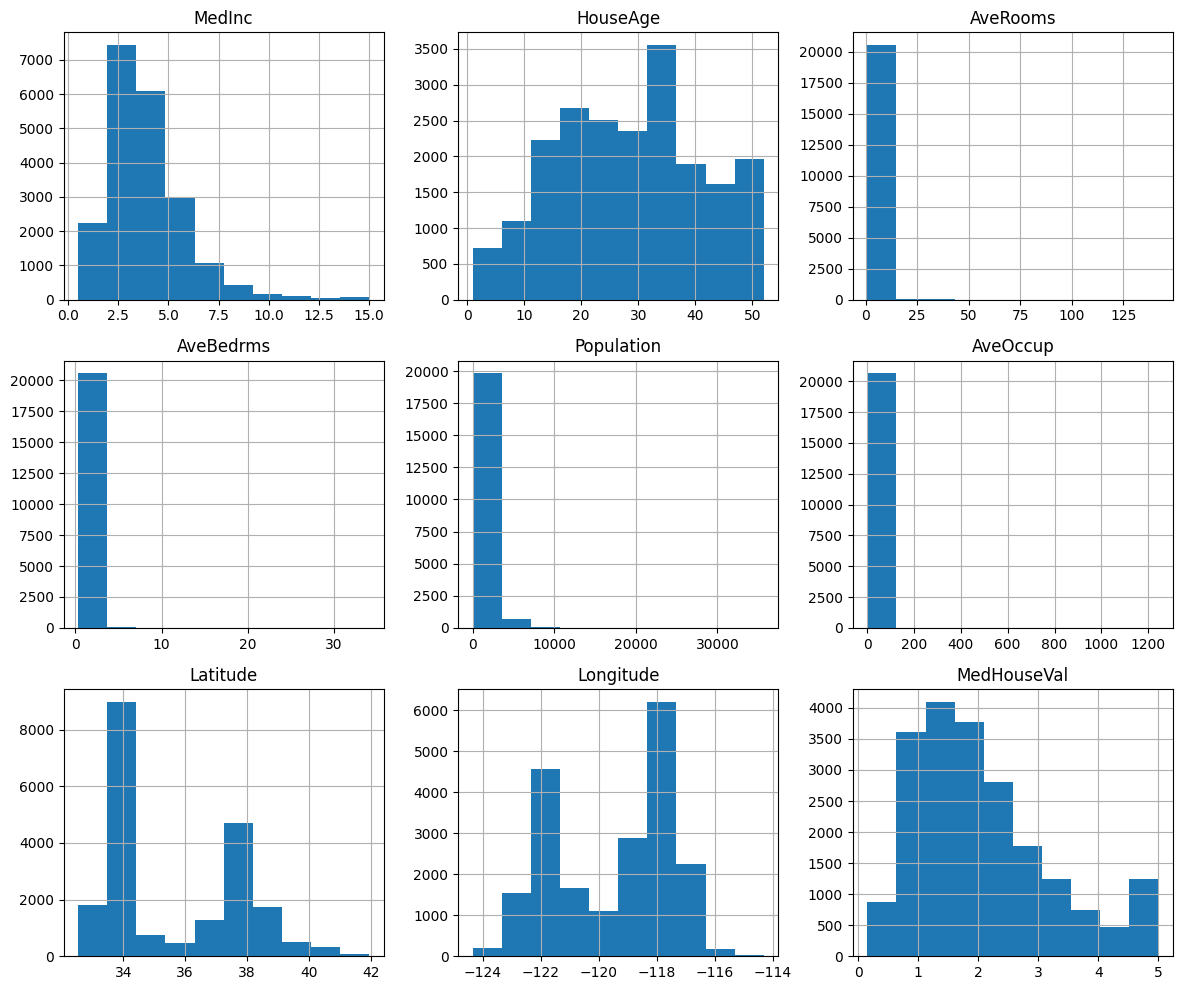

In [ ]:
#Histograms of variables
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

### Correlation Analysis

A correlation matrix is used to measure the strength of relationships between features.

The results show that median income (MedInc) has the strongest positive correlation with the target variable. Most other features have relatively weak correlations with the target.

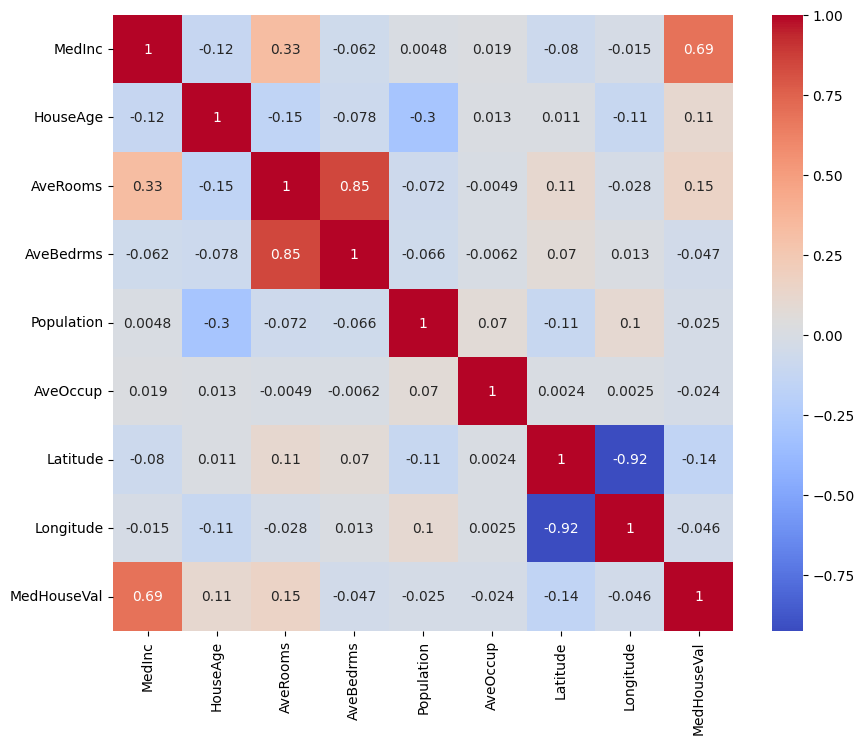

In [ ]:
#Correlations of variables
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

### Relationship Between Income and House Value

A scatter plot is used to examine the relationship between median income and house prices.

The relationship appears to be positive but not strictly linear. Additionally, the target variable seems to be capped at an upper limit, which may affect model performance.

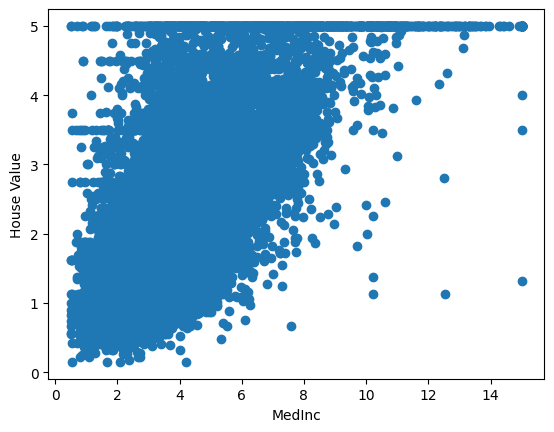

In [ ]:
#Scatter Plot
plt.scatter(df["MedInc"], df["MedHouseVal"])
plt.xlabel("MedInc")
plt.ylabel("House Value")
plt.show()

### EDA Summary

- Several features show skewed distributions, indicating the presence of outliers.
- Median income is the most important feature based on correlation.
- The relationship between features and the target is not fully linear.
- The target variable appears to be capped, which may affect model predictions.

## Model Implementation

In this section, we implement and compare three regression models: Linear Regression, Ridge Regression, and Random Forest Regressor.

### Data Splitting

The dataset is split into training (80%) and test (20%) sets. A fixed random seed is used to ensure reproducibility.

In [ ]:
#Split dataset into training and test sets (80/20 split)
from sklearn.model_selection import train_test_split

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

### Linear Regression

Linear Regression is used as a baseline model to capture linear relationships between features and the target variable.

In [ ]:
#Train Linear Regression model
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

In [ ]:
#Evaluate model performance using RMSE, MAE, and R2 (Linear Regression)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae = mean_absolute_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 0.7197380534040615
MAE: 0.5255457157103748
R2: 0.6104546894797874


### Ridge Regression

Ridge Regression adds L2 regularization to reduce overfitting. The optimal regularization parameter is selected using cross-validation.

In [ ]:
#Train Ridge Linear Regression model
from sklearn.linear_model import RidgeCV

alphas = [0.1, 1.0, 10.0, 100.0]

model_ridge = RidgeCV(alphas=alphas, cv=5)
model_ridge.fit(X_train, y_train)

y_pred_ridge = model_ridge.predict(X_test)

print("Best alpha:", model_ridge.alpha_)

Best alpha: 0.1


In [ ]:
#Evaluate model performance using RMSE, MAE, and R2 (Ridge Linear Regression)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae = mean_absolute_error(y_test, y_pred_ridge)
r2 = r2_score(y_test, y_pred_ridge)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 0.7197380301591795
MAE: 0.5255465437512299
R2: 0.6104547146415378


### Random Forest Regressor

Random Forest is an ensemble model that captures nonlinear relationships by combining multiple decision trees.

In [ ]:
#Train Random Forest model
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=123
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

In [ ]:
#Evaluate model performance using RMSE, MAE, and R2 (Random Forest)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 0.49978005130817216
MAE: 0.3241204125484498
R2: 0.8121691667094176


### Evaluation Metrics

We evaluate the models using RMSE, MAE, and R² scores.

In [ ]:
#Model Performance Comparison
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Random Forest"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_rf)
    ]
})

results.round(4)

,Model,RMSE,MAE,R2
0,Linear Regression,0.7197,0.5255,0.6105
1,Ridge,0.7197,0.5255,0.6105
2,Random Forest,0.4998,0.3241,0.8122


### Model Comparison

Random Forest significantly outperforms Linear and Ridge Regression, indicating that the relationships in the dataset are nonlinear. Linear-based models show moderate performance, while regularization does not provide significant improvements.

## Effect of Feature Scaling

Standard scaling is applied to the input features to examine whether scaling affects model performance. Scaling is especially relevant for linear models with regularization.

In [ ]:
#Standard Scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Linear Regression and Ridge Regression with Scaled Features

In [ ]:
#Linear Regression (scaled)
model_lr_scaled = LinearRegression()
model_lr_scaled.fit(X_train_scaled, y_train)

y_pred_lr_scaled = model_lr_scaled.predict(X_test_scaled)

In [ ]:
#Ridge Regression (scaled)
model_ridge_scaled = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0], cv=5)
model_ridge_scaled.fit(X_train_scaled, y_train)

y_pred_ridge_scaled = model_ridge_scaled.predict(X_test_scaled)

print("Best alpha (scaled):", model_ridge_scaled.alpha_)

Best alpha (scaled): 100.0


In [ ]:
#Calculation of metrics
print("Linear (Scaled)")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr_scaled)))
print("MAE:", mean_absolute_error(y_test, y_pred_lr_scaled))
print("R2:", r2_score(y_test, y_pred_lr_scaled))

print("\nRidge (Scaled)")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge_scaled)))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge_scaled))
print("R2:", r2_score(y_test, y_pred_ridge_scaled))

Linear (Scaled)
RMSE: 0.7197380534040614
MAE: 0.5255457157103737
R2: 0.6104546894797875

Ridge (Scaled)
RMSE: 0.7206556786047033
MAE: 0.5257903784702618
R2: 0.6094607599231215


Scaling had little effect on Linear Regression. For Ridge Regression, the selected alpha changed, but predictive performance did not improve significantly.

## Polynomial Features

Polynomial features of degree 2 are created to allow the linear model to capture nonlinear relationships and feature interactions.

In [ ]:
#Polynomial Features with Linear Regression (degree=2)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly_lr = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

poly_lr.fit(X_train, y_train)

y_pred_poly_lr = poly_lr.predict(X_test)

In [ ]:
print("Polynomial Linear Regression (Degree 2)")

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly_lr)))
print("MAE:", mean_absolute_error(y_test, y_pred_poly_lr))
print("R2:", r2_score(y_test, y_pred_poly_lr))

Polynomial Linear Regression (Degree 2)
RMSE: 0.7267264417648945
MAE: 0.459319605214221
R2: 0.602853284688204


Polynomial features did not improve overall performance. RMSE increased and R² decreased slightly, suggesting that the added complexity may not generalize well.

## Residual Analysis

Residual plots are used to examine whether model errors are randomly distributed or show systematic patterns.

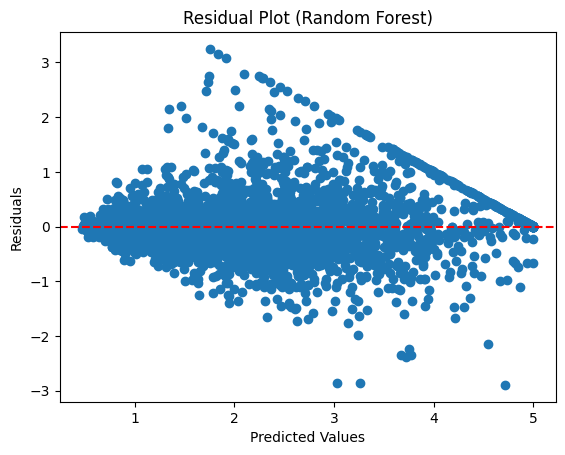

In [ ]:
#Residual plot
import matplotlib.pyplot as plt

residuals = y_test - y_pred_rf

plt.scatter(y_pred_rf, residuals)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Random Forest)")

plt.show()

The residual plot shows that errors are centered around zero, but they are not completely random. A visible pattern appears at higher predicted values, likely due to the capped target variable. The spread of residuals also changes across prediction ranges, indicating heteroscedasticity.

## Conclusion

The models’ performance was evaluated using standard regression metrics such as Mean Squared Error (MSE) and R-squared. XGBoost outperformed Linear Regression, demonstrating its ability to model complex relationships in the data.
The results demonstrate that linear regression has limits in capturing nonlinear interactions in the dataset. While it provides a straightforward and understandable base, its performance is limited when the underlying data patterns are complex.
In contrast, XGBoost outperforms due to its capacity to represent nonlinear interactions and merge several decision trees. This demonstrates the benefit of more flexible and robust models in regression tasks that use real-world data.